# 0d, 1d, 2d and 3d tight binding models
The same `Geometry`/`Hamiltonian` API is dimensionality-agnostic: `islands` builds finite (0d)
flakes, `geometry.chain()`/ribbons are 1d, `geometry.honeycomb_lattice()`/`triangular_lattice()`
are 2d, and `geometry.diamond_lattice()`/`cubic_lattice()` are 3d.
### Import the necessary libraries

In [1]:
# Add the root path of the pyqula library
import os ; import sys
sys.path.append(os.getcwd()+"/../../../src")

import numpy as np
import matplotlib.pyplot as plt
from pyqula import geometry
from pyqula import islands

In [2]:
g0d = islands.get_geometry(name="honeycomb",n=2,nedges=3)
g1d = geometry.chain()
g2d = geometry.honeycomb_lattice()
g3d = geometry.diamond_lattice()

for name,g in [("0d island",g0d),("1d chain",g1d),("2d honeycomb",g2d),("3d diamond",g3d)]:
    h = g.get_hamiltonian()
    print(f"{name:14s} dimensionality={g.dimensionality}  atoms/cell={len(g.r)}")

0d island      dimensionality=0  atoms/cell=33
1d chain       dimensionality=1  atoms/cell=1
2d honeycomb   dimensionality=2  atoms/cell=2
3d diamond     dimensionality=3  atoms/cell=2


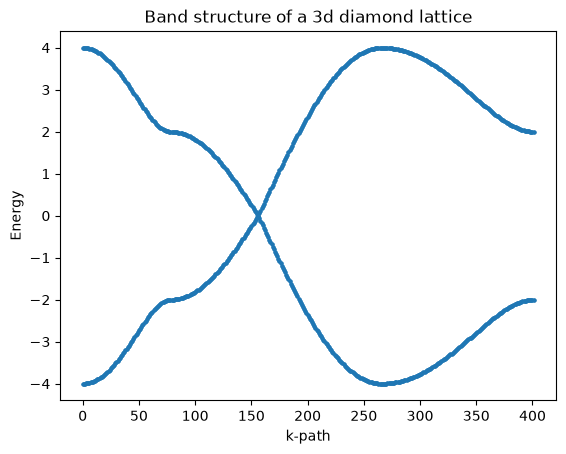

In [3]:
h3d = g3d.get_hamiltonian()
h3d.add_soc(0.1) # intrinsic spin-orbit coupling
(k,e) = h3d.get_bands()

plt.scatter(k,e,s=4)
plt.xlabel("k-path") ; plt.ylabel("Energy")
plt.title("Band structure of a 3d diamond lattice")
plt.show()

### The same observables in every dimensionality
The observables are computed with the same calls whatever the dimensionality. As an example, the
local density of states of the 0d island at zero energy, largest on the sites at the edge,
and the Fermi surface of the 2d honeycomb lattice above the Dirac points, made of trigonally warped
pockets around the K and K' valleys.

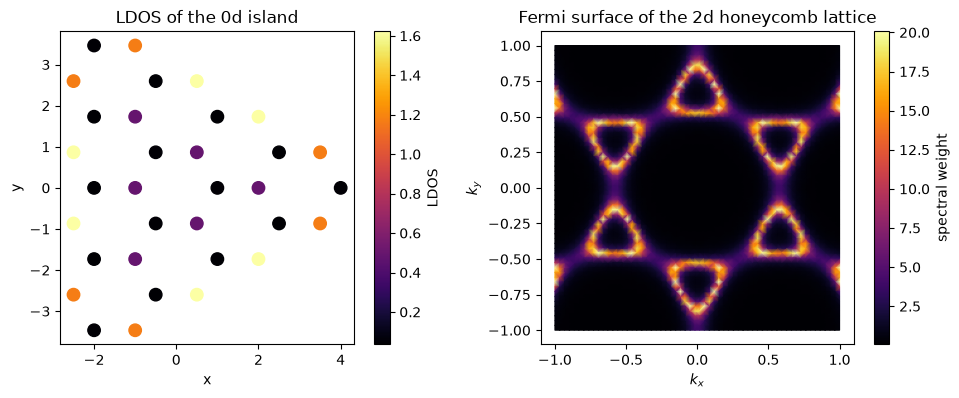

In [4]:
h0d = g0d.get_hamiltonian() # Hamiltonian of the 0d island
(x,y,d) = h0d.get_ldos(e=0.0,delta=0.1) # local density of states at zero energy

h2d = g2d.get_hamiltonian() # Hamiltonian of the 2d honeycomb lattice
(kx,ky,fs) = h2d.get_fermi_surface(e=0.8,nk=60,delta=0.1) # Fermi surface at energy 0.8

fig,axs = plt.subplots(1,2,figsize=(10,4))
s = axs[0].scatter(x,y,c=d,cmap="inferno",s=80)
fig.colorbar(s,ax=axs[0],label="LDOS")
axs[0].set_aspect("equal") ; axs[0].set_title("LDOS of the 0d island")
axs[0].set_xlabel("x") ; axs[0].set_ylabel("y")
s = axs[1].tripcolor(kx,ky,fs,cmap="inferno",shading="gouraud")
fig.colorbar(s,ax=axs[1],label="spectral weight")
axs[1].set_aspect("equal") ; axs[1].set_title("Fermi surface of the 2d honeycomb lattice")
axs[1].set_xlabel("$k_x$") ; axs[1].set_ylabel("$k_y$")
plt.tight_layout()
plt.show()